🔥 Warming up the CPU and OS RAM Cache...

🚀 Starting High-Precision Benchmark...

Running with 1 thread(s)... best time: 12.259s (out of 3 runs)
Running with 2 thread(s)... best time: 6.547s (out of 3 runs)
Running with 3 thread(s)... best time: 4.519s (out of 3 runs)
Running with 4 thread(s)... best time: 3.542s (out of 3 runs)
Running with 5 thread(s)... best time: 3.029s (out of 3 runs)
Running with 6 thread(s)... best time: 2.628s (out of 3 runs)
Running with 7 thread(s)... best time: 2.612s (out of 3 runs)
Running with 8 thread(s)... best time: 2.511s (out of 3 runs)
Running with 9 thread(s)... best time: 2.417s (out of 3 runs)
Running with 10 thread(s)... best time: 2.386s (out of 3 runs)
Running with 11 thread(s)... best time: 2.348s (out of 3 runs)
Running with 12 thread(s)... best time: 2.332s (out of 3 runs)
Running with 13 thread(s)... best time: 2.287s (out of 3 runs)
Running with 14 thread(s)... best time: 2.286s (out of 3 runs)
Running with 15 thread(s)... best time: 2.29

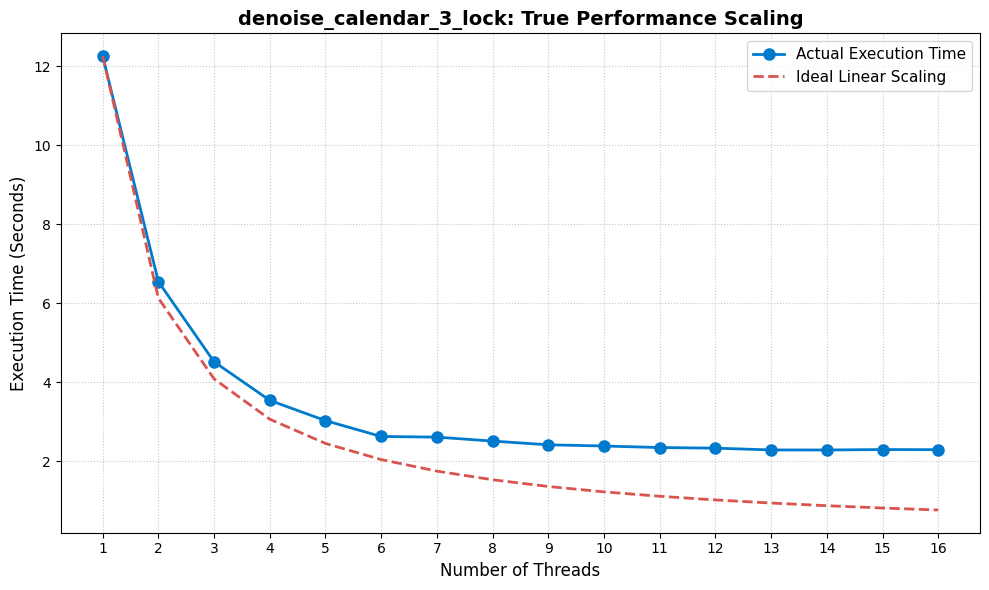

In [4]:
import subprocess
import time
import matplotlib.pyplot as plt
import csv
import os

# --- CONFIGURATION ---
PROGRAM_CMD = ['./../denoise_calendar_3_lock', '../noise.ppm', 'result.ppm']
THREAD_COUNTS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
RUNS_PER_TEST = 3  # Run each test 3 times to filter out OS noise
CSV_FILENAME = 'benchmark_results.csv'
# ---------------------

# Extract just the program name for the CSV (e.g., 'denoise_calendar_3')
program_name = PROGRAM_CMD[0].split('/')[-1]

print("🔥 Warming up the CPU and OS RAM Cache...")
# This run is NOT timed. It just forces the file into memory and wakes up the CPU.
subprocess.run(PROGRAM_CMD + ['1'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

execution_times = []

# --- CSV SETUP ---
# Check if file exists so we know whether to write the header row
write_header = not os.path.isfile(CSV_FILENAME)

with open(CSV_FILENAME, mode='a', newline='') as csv_file:
    writer = csv.writer(csv_file)
    if write_header:
        writer.writerow(['Program Name', 'Thread Count', 'Time (Seconds)'])

    print("\n🚀 Starting High-Precision Benchmark...\n")

    for threads in THREAD_COUNTS:
        print(f"Running with {threads} thread(s)...", end="", flush=True)
        
        times_for_this_thread = []
        
        for _ in range(RUNS_PER_TEST):
            cmd = PROGRAM_CMD + [str(threads)]
            
            start_time = time.perf_counter()
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            end_time = time.perf_counter()
            
            times_for_this_thread.append(end_time - start_time)
        
        # Take the MINIMUM time. This is the run where the OS interrupted us the least!
        best_time = min(times_for_this_thread)
        execution_times.append(best_time)
        
        # Write the result directly to the CSV
        writer.writerow([program_name, threads, best_time])
        
        print(f" best time: {best_time:.3f}s (out of {RUNS_PER_TEST} runs)")

print(f"\n💾 Raw data appended to {CSV_FILENAME}")
print("📊 Benchmarks complete! Generating graph...")

# Calculate ideal scaling based on the completely warmed-up 1-thread time
base_time = execution_times[0]
ideal_times = [base_time / t for t in THREAD_COUNTS]

# Draw the graph
plt.figure(figsize=(10, 6))
plt.plot(THREAD_COUNTS, execution_times, marker='o', markersize=8, 
         linestyle='-', color='#007acc', linewidth=2, label='Actual Execution Time')
plt.plot(THREAD_COUNTS, ideal_times, marker='', 
         linestyle='--', color='#d9534f', linewidth=2, label='Ideal Linear Scaling')

plt.title(f'{program_name}: True Performance Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Execution Time (Seconds)', fontsize=12)
plt.xticks(THREAD_COUNTS)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
graph_filename = f'scaling_graph_{program_name}.png'
plt.savefig(graph_filename, dpi=300)
print(f"✅ Graph saved successfully as '{graph_filename}'!")

🔥 Warming up the CPU and OS RAM Cache...

🚀 Starting High-Precision Benchmark...

Running with 1 thread(s)... best time: 11.935s (out of 3 runs)
Running with 2 thread(s)... best time: 6.997s (out of 3 runs)
Running with 3 thread(s)... best time: 4.766s (out of 3 runs)
Running with 4 thread(s)... best time: 3.808s (out of 3 runs)
Running with 5 thread(s)... best time: 3.203s (out of 3 runs)
Running with 6 thread(s)... best time: 2.846s (out of 3 runs)
Running with 7 thread(s)... best time: 3.112s (out of 3 runs)
Running with 8 thread(s)... best time: 2.849s (out of 3 runs)
Running with 9 thread(s)... best time: 2.652s (out of 3 runs)
Running with 10 thread(s)... best time: 2.592s (out of 3 runs)
Running with 11 thread(s)... best time: 2.502s (out of 3 runs)
Running with 12 thread(s)... best time: 2.448s (out of 3 runs)
Running with 13 thread(s)... best time: 2.504s (out of 3 runs)
Running with 14 thread(s)... best time: 2.503s (out of 3 runs)
Running with 15 thread(s)... best time: 2.50

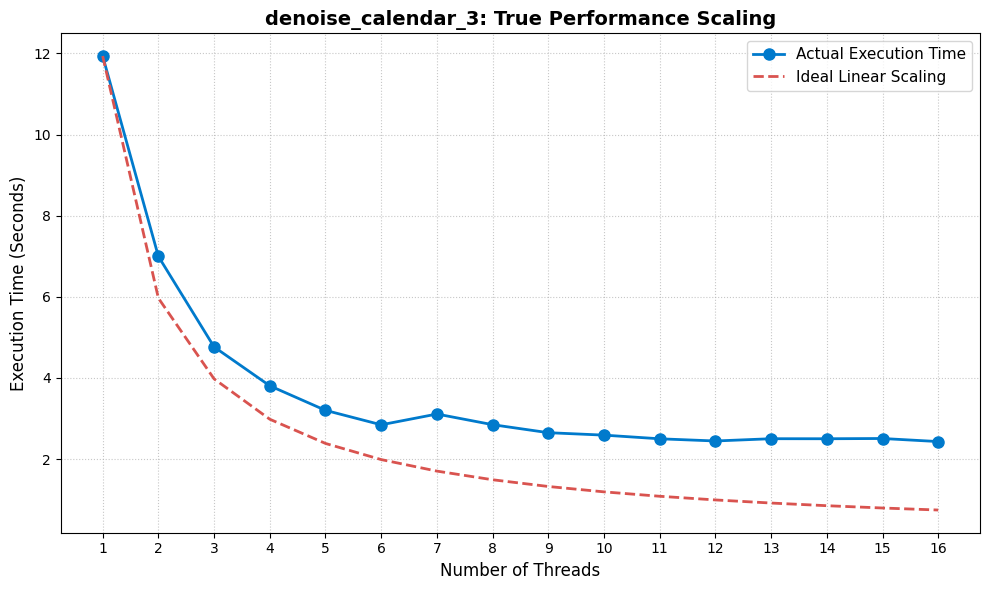

In [3]:
import subprocess
import time
import matplotlib.pyplot as plt
import csv
import os

# --- CONFIGURATION ---
PROGRAM_CMD = ['./../denoise_calendar_3', '../noise.ppm', 'result.ppm']
THREAD_COUNTS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
RUNS_PER_TEST = 3  # Run each test 3 times to filter out OS noise
CSV_FILENAME = 'benchmark_results.csv'
# ---------------------

# Extract just the program name for the CSV (e.g., 'denoise_calendar_3')
program_name = PROGRAM_CMD[0].split('/')[-1]

print("🔥 Warming up the CPU and OS RAM Cache...")
# This run is NOT timed. It just forces the file into memory and wakes up the CPU.
subprocess.run(PROGRAM_CMD + ['1'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

execution_times = []

# --- CSV SETUP ---
# Check if file exists so we know whether to write the header row
write_header = not os.path.isfile(CSV_FILENAME)

with open(CSV_FILENAME, mode='a', newline='') as csv_file:
    writer = csv.writer(csv_file)
    if write_header:
        writer.writerow(['Program Name', 'Thread Count', 'Time (Seconds)'])

    print("\n🚀 Starting High-Precision Benchmark...\n")

    for threads in THREAD_COUNTS:
        print(f"Running with {threads} thread(s)...", end="", flush=True)
        
        times_for_this_thread = []
        
        for _ in range(RUNS_PER_TEST):
            cmd = PROGRAM_CMD + [str(threads)]
            
            start_time = time.perf_counter()
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            end_time = time.perf_counter()
            
            times_for_this_thread.append(end_time - start_time)
        
        # Take the MINIMUM time. This is the run where the OS interrupted us the least!
        best_time = min(times_for_this_thread)
        execution_times.append(best_time)
        
        # Write the result directly to the CSV
        writer.writerow([program_name, threads, best_time])
        
        print(f" best time: {best_time:.3f}s (out of {RUNS_PER_TEST} runs)")

print(f"\n💾 Raw data appended to {CSV_FILENAME}")
print("📊 Benchmarks complete! Generating graph...")

# Calculate ideal scaling based on the completely warmed-up 1-thread time
base_time = execution_times[0]
ideal_times = [base_time / t for t in THREAD_COUNTS]

# Draw the graph
plt.figure(figsize=(10, 6))
plt.plot(THREAD_COUNTS, execution_times, marker='o', markersize=8, 
         linestyle='-', color='#007acc', linewidth=2, label='Actual Execution Time')
plt.plot(THREAD_COUNTS, ideal_times, marker='', 
         linestyle='--', color='#d9534f', linewidth=2, label='Ideal Linear Scaling')

plt.title(f'{program_name}: True Performance Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Execution Time (Seconds)', fontsize=12)
plt.xticks(THREAD_COUNTS)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
graph_filename = f'scaling_graph_{program_name}.png'
plt.savefig(graph_filename, dpi=300)
print(f"✅ Graph saved successfully as '{graph_filename}'!")

🔥 Warming up the CPU and OS RAM Cache...

🚀 Starting High-Precision Benchmark...

Running with 1 thread(s)... best time: 11.965s (out of 3 runs)
Running with 2 thread(s)... best time: 6.513s (out of 3 runs)
Running with 3 thread(s)... best time: 4.629s (out of 3 runs)
Running with 4 thread(s)... best time: 3.534s (out of 3 runs)
Running with 5 thread(s)... best time: 3.070s (out of 3 runs)
Running with 6 thread(s)... best time: 2.692s (out of 3 runs)
Running with 7 thread(s)... best time: 2.737s (out of 3 runs)
Running with 8 thread(s)... best time: 2.622s (out of 3 runs)
Running with 9 thread(s)... best time: 2.529s (out of 3 runs)
Running with 10 thread(s)... best time: 2.470s (out of 3 runs)
Running with 11 thread(s)... best time: 2.376s (out of 3 runs)
Running with 12 thread(s)... best time: 2.310s (out of 3 runs)
Running with 13 thread(s)... best time: 2.331s (out of 3 runs)
Running with 14 thread(s)... best time: 2.332s (out of 3 runs)
Running with 15 thread(s)... best time: 2.32

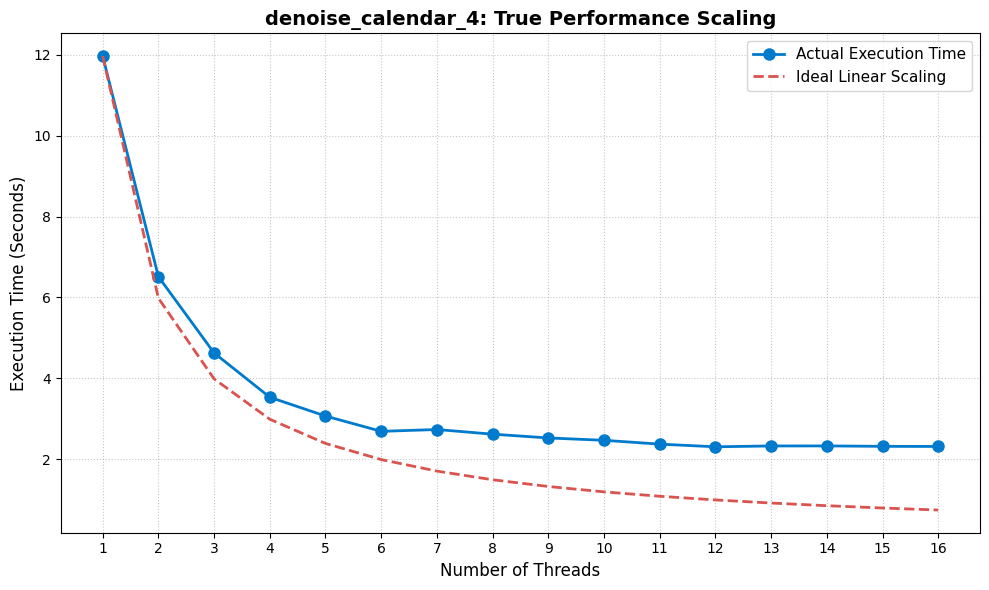

In [5]:
import subprocess
import time
import matplotlib.pyplot as plt
import csv
import os

# --- CONFIGURATION ---
PROGRAM_CMD = ['./../denoise_calendar_4', '../noise.ppm', 'result.ppm']
THREAD_COUNTS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
RUNS_PER_TEST = 3  # Run each test 3 times to filter out OS noise
CSV_FILENAME = 'benchmark_results.csv'
# ---------------------

# Extract just the program name for the CSV (e.g., 'denoise_calendar_3')
program_name = PROGRAM_CMD[0].split('/')[-1]

print("🔥 Warming up the CPU and OS RAM Cache...")
# This run is NOT timed. It just forces the file into memory and wakes up the CPU.
subprocess.run(PROGRAM_CMD + ['1'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

execution_times = []

# --- CSV SETUP ---
# Check if file exists so we know whether to write the header row
write_header = not os.path.isfile(CSV_FILENAME)

with open(CSV_FILENAME, mode='a', newline='') as csv_file:
    writer = csv.writer(csv_file)
    if write_header:
        writer.writerow(['Program Name', 'Thread Count', 'Time (Seconds)'])

    print("\n🚀 Starting High-Precision Benchmark...\n")

    for threads in THREAD_COUNTS:
        print(f"Running with {threads} thread(s)...", end="", flush=True)
        
        times_for_this_thread = []
        
        for _ in range(RUNS_PER_TEST):
            cmd = PROGRAM_CMD + [str(threads)]
            
            start_time = time.perf_counter()
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            end_time = time.perf_counter()
            
            times_for_this_thread.append(end_time - start_time)
        
        # Take the MINIMUM time. This is the run where the OS interrupted us the least!
        best_time = min(times_for_this_thread)
        execution_times.append(best_time)
        
        # Write the result directly to the CSV
        writer.writerow([program_name, threads, best_time])
        
        print(f" best time: {best_time:.3f}s (out of {RUNS_PER_TEST} runs)")

print(f"\n💾 Raw data appended to {CSV_FILENAME}")
print("📊 Benchmarks complete! Generating graph...")

# Calculate ideal scaling based on the completely warmed-up 1-thread time
base_time = execution_times[0]
ideal_times = [base_time / t for t in THREAD_COUNTS]

# Draw the graph
plt.figure(figsize=(10, 6))
plt.plot(THREAD_COUNTS, execution_times, marker='o', markersize=8, 
         linestyle='-', color='#007acc', linewidth=2, label='Actual Execution Time')
plt.plot(THREAD_COUNTS, ideal_times, marker='', 
         linestyle='--', color='#d9534f', linewidth=2, label='Ideal Linear Scaling')

plt.title(f'{program_name}: True Performance Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Execution Time (Seconds)', fontsize=12)
plt.xticks(THREAD_COUNTS)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
graph_filename = f'scaling_graph_{program_name}.png'
plt.savefig(graph_filename, dpi=300)
print(f"✅ Graph saved successfully as '{graph_filename}'!")

In [1]:
import subprocess
import time
import matplotlib.pyplot as plt
import csv
import os
import statistics

# --- CONFIGURATION ---
PROGRAM_CMD = ['./../denoise_calendar_final', '../noise.ppm', 'result.ppm']
THREAD_COUNTS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
RUNS_PER_TEST = 30  # Run each test 30 times for a statistically significant mean
CSV_FILENAME = 'benchmark_results_detailed.csv' # Changed filename to avoid column mismatch with old data
# ---------------------

# Extract just the program name for the CSV (e.g., 'denoise_calendar_3')
program_name = PROGRAM_CMD[0].split('/')[-1]

print("🔥 Warming up the CPU and OS RAM Cache...")
# This run is NOT timed. It just forces the file into memory and wakes up the CPU.
subprocess.run(PROGRAM_CMD + ['1'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# This will store the MEAN execution times for the graph
mean_execution_times = []

# --- CSV SETUP ---
# Check if file exists so we know whether to write the header row
write_header = not os.path.isfile(CSV_FILENAME)

with open(CSV_FILENAME, mode='a', newline='') as csv_file:
    writer = csv.writer(csv_file)
    if write_header:
        # Added 'Repetition' to the header
        writer.writerow(['Program Name', 'Thread Count', 'Repetition', 'Time (Seconds)'])

    print("\n🚀 Starting High-Precision Benchmark (30 Runs per Thread Count)...\n")

    for threads in THREAD_COUNTS:
        print(f"Running with {threads} thread(s)...", end="", flush=True)
        
        times_for_this_thread = []
        
        for rep in range(RUNS_PER_TEST):
            cmd = PROGRAM_CMD + [str(threads)]
            
            start_time = time.perf_counter()
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            end_time = time.perf_counter()
            
            run_time = end_time - start_time
            times_for_this_thread.append(run_time)
            
            # Write EACH individual repetition to the CSV immediately
            # rep + 1 so it counts from 1 to 30 instead of 0 to 29
            writer.writerow([program_name, threads, rep + 1, run_time])
            
            # Force write to disk just in case the script is interrupted
            csv_file.flush() 
        
        # Calculate the MEAN time for the console output and the graph
        mean_time = statistics.mean(times_for_this_thread)
        mean_execution_times.append(mean_time)
        
        print(f" mean time: {mean_time:.3f}s")

print(f"\n💾 All raw repetition data appended to {CSV_FILENAME}")
print("📊 Benchmarks complete! Generating graph of Mean Times...")

# Calculate ideal scaling based on the completely warmed-up 1-thread MEAN time
base_time = mean_execution_times[0]
ideal_times = [base_time / t for t in THREAD_COUNTS]

# Draw the graph
plt.figure(figsize=(10, 6))
plt.plot(THREAD_COUNTS, mean_execution_times, marker='o', markersize=8, 
         linestyle='-', color='#007acc', linewidth=2, label='Mean Execution Time (30 runs)')
plt.plot(THREAD_COUNTS, ideal_times, marker='', 
         linestyle='--', color='#d9534f', linewidth=2, label='Ideal Linear Scaling')

plt.title(f'{program_name}: True Performance Scaling (Means)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Mean Execution Time (Seconds)', fontsize=12)
plt.xticks(THREAD_COUNTS)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
graph_filename = f'scaling_graph_{program_name}.png'
plt.savefig(graph_filename, dpi=300)
print(f"✅ Graph saved successfully as '{graph_filename}'!")

🔥 Warming up the CPU and OS RAM Cache...

🚀 Starting High-Precision Benchmark (30 Runs per Thread Count)...

Running with 1 thread(s)... mean time: 13.447s
Running with 2 thread(s)... mean time: 7.296s
Running with 3 thread(s)... mean time: 5.072s
Running with 4 thread(s)... mean time: 3.932s
Running with 5 thread(s)... mean time: 3.380s
Running with 6 thread(s)...

KeyboardInterrupt: 

In [2]:
import subprocess
import time
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
PROGRAM_CMD = ['./../denoise', '../noise.ppm', 'result.ppm']
THREAD_COUNTS = [1, 2, 3, 4, 5, 6,7, 8,9, 10,11, 12, 13, 14, 15, 16]
RUNS_PER_TEST = 3  # Run each test 3 times to filter out OS noise
# ---------------------

print("🔥 Warming up the CPU and OS RAM Cache...")
# This run is NOT timed. It just forces the file into memory and wakes up the CPU.
subprocess.run(PROGRAM_CMD + ['1'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

execution_times = []

print("\n🚀 Starting High-Precision Benchmark...\n")

for threads in THREAD_COUNTS:
    print(f"Running with {threads} thread(s)...", end="", flush=True)
    
    times_for_this_thread = []
    
    for _ in range(RUNS_PER_TEST):
        cmd = PROGRAM_CMD + [str(threads)]
        
        start_time = time.perf_counter()
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        end_time = time.perf_counter()
        
        times_for_this_thread.append(end_time - start_time)
    
    # Take the MINIMUM time. This is the run where the OS interrupted us the least!
    best_time = min(times_for_this_thread)
    execution_times.append(best_time)
    
    print(f" best time: {best_time:.3f}s (out of {RUNS_PER_TEST} runs)")

print("\n📊 Benchmarks complete! Generating graph...")

# Calculate ideal scaling based on the completely warmed-up 1-thread time
base_time = execution_times[0]
ideal_times = [base_time / t for t in THREAD_COUNTS]

# Draw the graph
plt.figure(figsize=(10, 6))
plt.plot(THREAD_COUNTS, execution_times, marker='o', markersize=8, 
         linestyle='-', color='#007acc', linewidth=2, label='Actual Execution Time')
plt.plot(THREAD_COUNTS, ideal_times, marker='', 
         linestyle='--', color='#d9534f', linewidth=2, label='Ideal Linear Scaling')

plt.title('Adaptive Median Filter: True Performance Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Execution Time (Seconds)', fontsize=12)
plt.xticks(THREAD_COUNTS)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('scaling_graph_warmed_up.png', dpi=300)
print("✅ Graph saved successfully as 'scaling_graph_warmed_up.png'!")

🔥 Warming up the CPU and OS RAM Cache...


KeyboardInterrupt: 

Loading data from benchmark_results.csv...
✅ Graph successfully generated and saved as 'algorithm_comparison.png'!


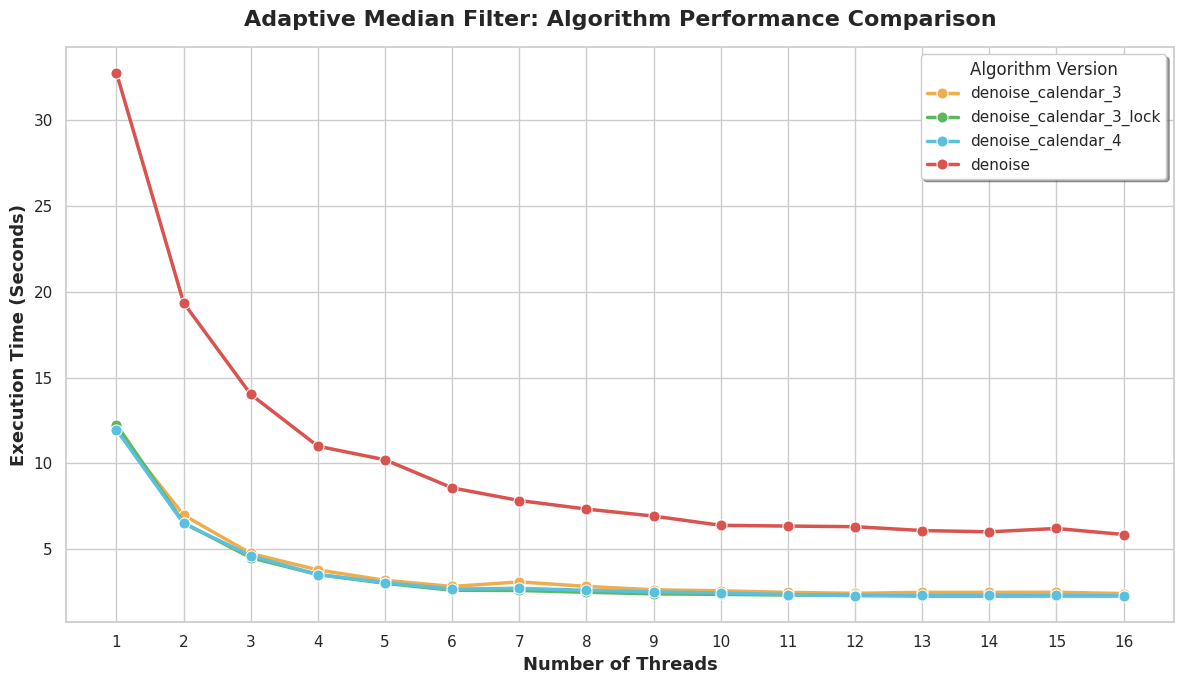

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
CSV_FILENAME = 'benchmark_results.csv'
OUTPUT_GRAPH = 'algorithm_comparison.png'

print(f"Loading data from {CSV_FILENAME}...")

# Load the CSV data using Pandas
try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'. Make sure you are running the script in the right directory.")
    exit(1)

# Set up the plot style for a clean, academic look
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Define a custom color palette so the lines are easy to distinguish
custom_palette = {
    'denoise': '#d9534f',                # Red (The slow baseline)
    'denoise_calendar_3': '#f0ad4e',     # Orange
    'denoise_calendar_4': '#5bc0de',     # Light Blue
    'denoise_calendar_3_lock': '#5cb85c' # Green (The locked-in winner!)
}

# Plot the data
ax = sns.lineplot(
    data=df,
    x='Thread Count',
    y='Time (Seconds)',
    hue='Program Name',
    marker='o',
    markersize=8,
    linewidth=2.5,
    palette=custom_palette
)

# Formatting
plt.title('Adaptive Median Filter: Algorithm Performance Comparison', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Threads', fontsize=13, fontweight='bold')
plt.ylabel('Execution Time (Seconds)', fontsize=13, fontweight='bold')

# Ensure all thread counts are visible on the X-axis
thread_counts = df['Thread Count'].unique()
plt.xticks(thread_counts)

# Customize the legend
plt.legend(title='Algorithm Version', title_fontsize='12', fontsize='11', shadow=True)

# Save the graph
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")

# Display it on screen (if you aren't running headlessly)
plt.show()

Loading data from benchmark_results.csv...
✅ Graph successfully generated and saved as 'optimized_comparison_zoomed.png'!


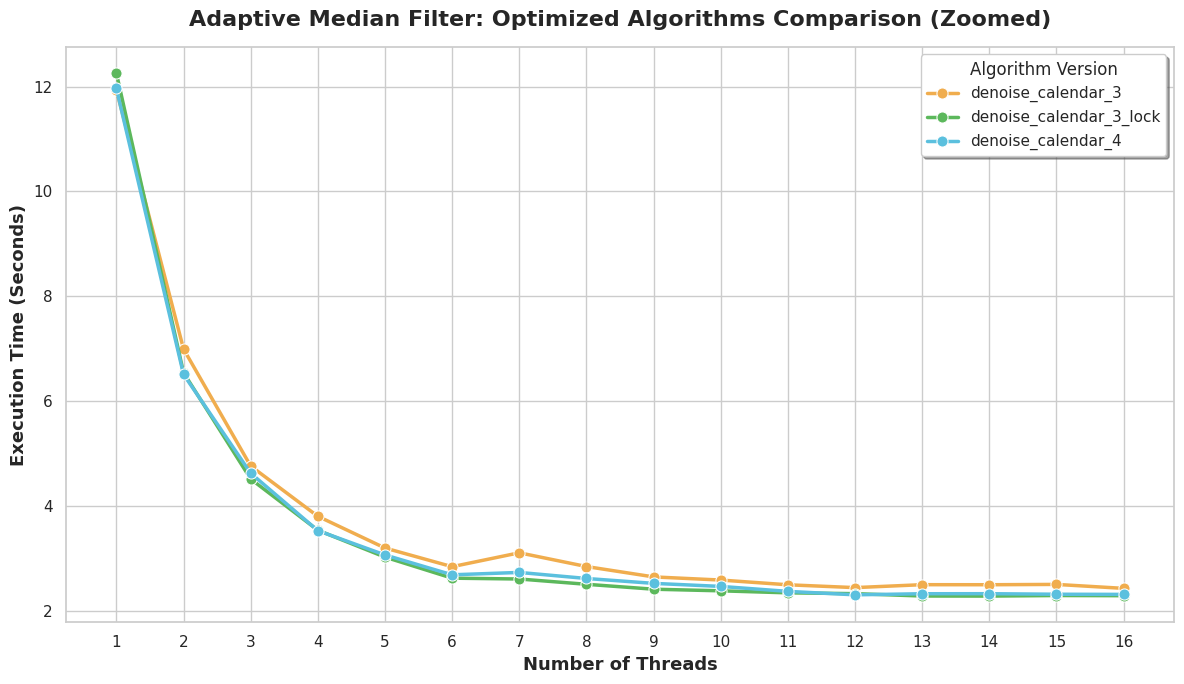

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
CSV_FILENAME = 'benchmark_results.csv'
OUTPUT_GRAPH = 'optimized_comparison_zoomed.png'

print(f"Loading data from {CSV_FILENAME}...")

# Load the CSV data using Pandas
try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'.")
    exit(1)

# --- THE FILTER ---
# Keep only the rows where the Program Name is NOT 'denoise'
df_filtered = df[df['Program Name'] != 'denoise']

# Set up the plot style
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Custom color palette for the remaining three optimized programs
custom_palette = {
    'denoise_calendar_3': '#f0ad4e',     # Orange
    'denoise_calendar_4': '#5bc0de',     # Light Blue
    'denoise_calendar_3_lock': '#5cb85c' # Green
}

# Plot the filtered data
ax = sns.lineplot(
    data=df_filtered,
    x='Thread Count',
    y='Time (Seconds)',
    hue='Program Name',
    marker='o',
    markersize=8,
    linewidth=2.5,
    palette=custom_palette
)

# Formatting
plt.title('Adaptive Median Filter: Optimized Algorithms Comparison (Zoomed)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Threads', fontsize=13, fontweight='bold')
plt.ylabel('Execution Time (Seconds)', fontsize=13, fontweight='bold')

# Ensure all thread counts are visible on the X-axis
thread_counts = df_filtered['Thread Count'].unique()
plt.xticks(thread_counts)

# Customize the legend
plt.legend(title='Algorithm Version', title_fontsize='12', fontsize='11', shadow=True)

# Save the graph
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")

# Display it on screen
plt.show()

Loading data from benchmark_results.csv...


/tmp/ipykernel_3034/2516113713.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


✅ Graph successfully generated and saved as 'barplot_12_threads.png'!


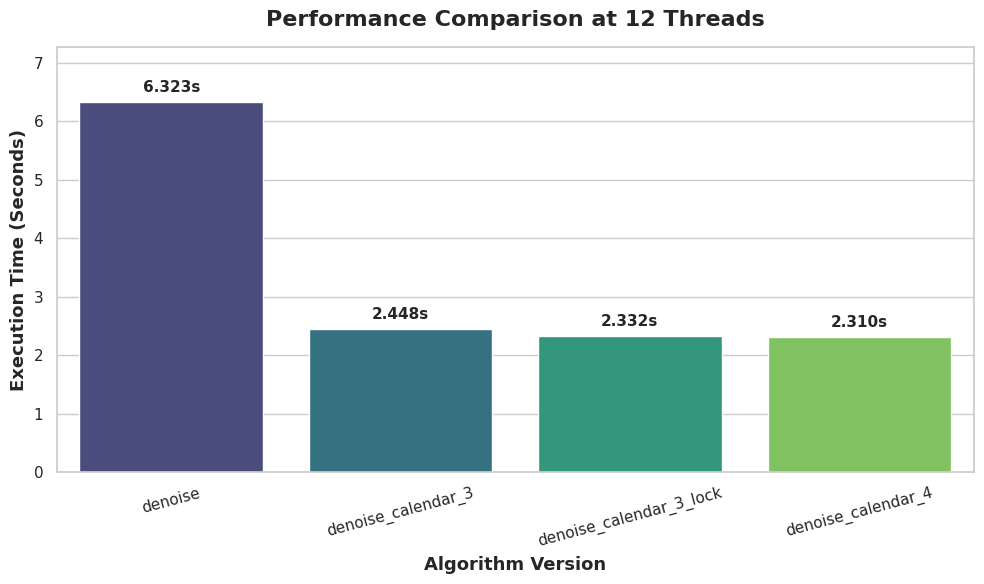

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
CSV_FILENAME = 'benchmark_results.csv'
OUTPUT_GRAPH = 'barplot_12_threads.png'
TARGET_THREADS = 12

print(f"Loading data from {CSV_FILENAME}...")

try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'.")
    exit(1)

# --- FILTER FOR 12 THREADS ---
df_12 = df[df['Thread Count'] == TARGET_THREADS].copy()

if df_12.empty:
    print(f"Error: No data found for {TARGET_THREADS} threads.")
    exit(1)

# Sort the values from slowest to fastest so the graph tells a story
df_12 = df_12.sort_values(by='Time (Seconds)', ascending=False)

# Set up the plot style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=df_12,
    x='Program Name',
    y='Time (Seconds)',
    palette='viridis' # A nice gradient color scheme
)

# Formatting
plt.title(f'Performance Comparison at {TARGET_THREADS} Threads', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Algorithm Version', fontsize=13, fontweight='bold')
plt.ylabel('Execution Time (Seconds)', fontsize=13, fontweight='bold')

# Rotate the X-axis labels slightly so the program names don't overlap
plt.xticks(rotation=15)

# --- ADD EXACT NUMBERS ON TOP OF BARS ---
for p in ax.patches:
    height = p.get_height()
    # Place the text exactly at the top of the bar
    ax.annotate(f'{height:.3f}s', 
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5), # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Extend the Y-axis slightly so the text labels don't get cut off at the top
plt.ylim(0, df_12['Time (Seconds)'].max() * 1.15)

# Save the graph
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")

# Display it
plt.show()

Loading data from benchmark_results.csv...
Baseline Serial Time (denoise @ 1 thread): 32.714 seconds
✅ Graph successfully generated and saved as 'speedup_comparison.png'!


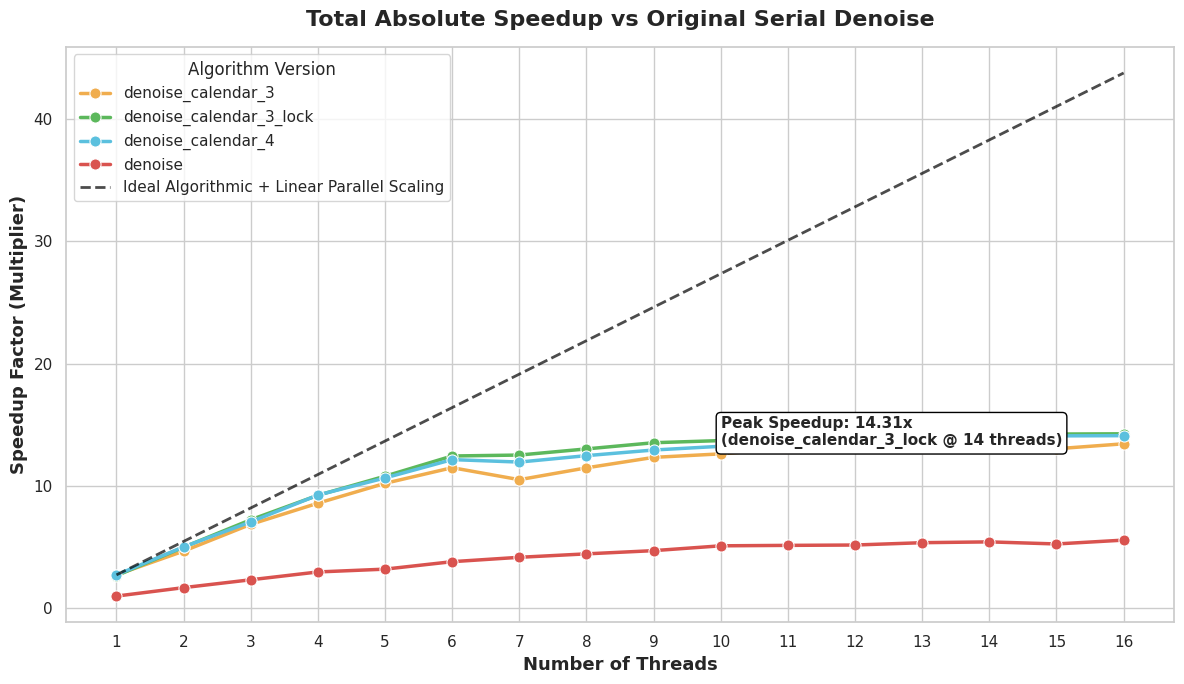

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
CSV_FILENAME = 'benchmark_results.csv'
OUTPUT_GRAPH = 'speedup_comparison.png'

print(f"Loading data from {CSV_FILENAME}...")

try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'.")
    exit(1)

# 1. FIND THE ABSOLUTE BASELINE
# This is the time of the original 'denoise' program running on exactly 1 thread
baseline_serial_time = df[(df['Program Name'] == 'denoise') & (df['Thread Count'] == 1)]['Time (Seconds)'].values[0]
print(f"Baseline Serial Time (denoise @ 1 thread): {baseline_serial_time:.3f} seconds")

# 2. CALCULATE SPEEDUP FOR EVERY ROW
# Speedup = (Time of original serial baseline) / (Time of parallel run)
df['Speedup'] = baseline_serial_time / df['Time (Seconds)']

# Set up the plot style
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

custom_palette = {
    'denoise': '#d9534f',                # Red
    'denoise_calendar_3': '#f0ad4e',     # Orange
    'denoise_calendar_4': '#5bc0de',     # Light Blue
    'denoise_calendar_3_lock': '#5cb85c' # Green
}

# Plot the actual speedup lines
ax = sns.lineplot(
    data=df,
    x='Thread Count',
    y='Speedup',
    hue='Program Name',
    marker='o',
    markersize=8,
    linewidth=2.5,
    palette=custom_palette
)

# 3. PLOT THE THEORETICAL IDEAL SCALING
# Ideal scaling assumes a 1:1 speedup per thread (e.g., 4 threads = 4x speedup)
# But we must adjust it because our NEW algorithms are inherently faster even on 1 thread.
# Best 1-thread time is calendar_4 (~11.96s). The algorithmic speedup alone is 32.71 / 11.96 = ~2.73x.
# Ideal multithreaded speedup = 2.73 * Thread Count
best_1_thread_time = df[(df['Program Name'] == 'denoise_calendar_4') & (df['Thread Count'] == 1)]['Time (Seconds)'].values[0]
algorithmic_advantage = baseline_serial_time / best_1_thread_time

thread_counts = sorted(df['Thread Count'].unique())
ideal_speedups = [algorithmic_advantage * t for t in thread_counts]

plt.plot(thread_counts, ideal_speedups, linestyle='--', color='black', linewidth=2, alpha=0.7, label='Ideal Algorithmic + Linear Parallel Scaling')

# Formatting
plt.title('Total Absolute Speedup vs Original Serial Denoise', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Threads', fontsize=13, fontweight='bold')
plt.ylabel('Speedup Factor (Multiplier)', fontsize=13, fontweight='bold')
plt.xticks(thread_counts)

# Customize the legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Algorithm Version', fontsize='11')

# Add a text box highlighting the maximum speedup achieved
max_speedup = df['Speedup'].max()
best_prog = df.loc[df['Speedup'].idxmax()]['Program Name']
best_threads = df.loc[df['Speedup'].idxmax()]['Thread Count']

plt.annotate(f'Peak Speedup: {max_speedup:.2f}x\n({best_prog} @ {best_threads} threads)', 
             xy=(best_threads, max_speedup), 
             xytext=(best_threads - 4, max_speedup - 1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

# Save the graph
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")

# Display it
plt.show()

Loading data from benchmark_results_detailed.csv...
✅ Graph successfully generated and saved as 'benchmark_confidence_99.png'!


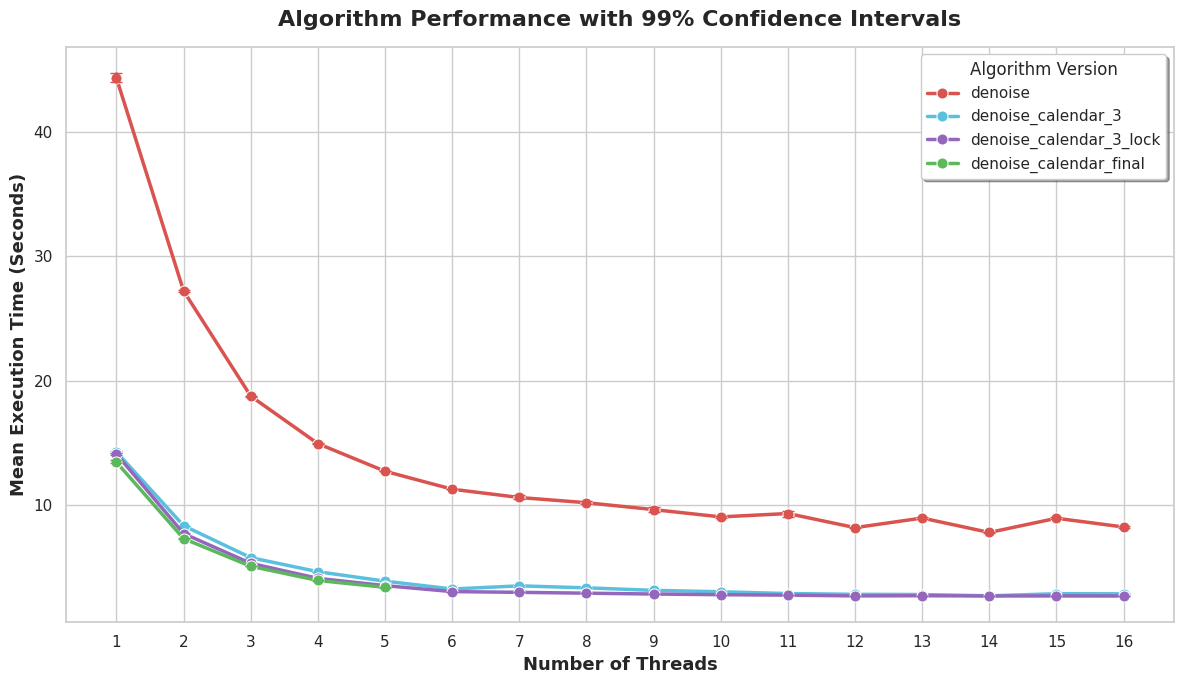

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
CSV_FILENAME = 'benchmark_results_detailed.csv'
OUTPUT_GRAPH = 'benchmark_confidence_99.png'

print(f"Loading data from {CSV_FILENAME}...")

try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'.")
    exit(1)

# Set up the plot style for a clean, academic look
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Define a custom color palette
custom_palette = {
    'denoise': '#d9534f',                   # Red
    'denoise_calendar_1': '#8c564b',        # Brown (Naive)
    'denoise_calendar_dynamic_naive': '#f0ad4e', # Orange
    'denoise_calendar_3': '#5bc0de',        # Light Blue
    'denoise_calendar_final': '#5cb85c',        # Green (Optimized)
    'denoise_calendar_3_lock': '#9467bd'    # Purple
}

# --- THE MAGIC HAPPENS HERE ---
# Seaborn automatically calculates the mean of 'Time (Seconds)' for each 'Thread Count'
# errorbar=('ci', 99) tells it to calculate and draw the 99% Confidence Interval shading!
ax = sns.lineplot(
    data=df,
    x='Thread Count',
    y='Time (Seconds)',
    hue='Program Name',
    marker='o',
    markersize=8,
    linewidth=2.5,
    err_style="bars",      # Changes from shaded bands to vertical bars
    err_kws={'capsize': 4, 'elinewidth': 2}, # Adds the caps to the top/bottom of the bars
    errorbar=('ci', 99),         # Use Standard Deviation
    palette=custom_palette
)
# Formatting
plt.title('Algorithm Performance with 99% Confidence Intervals', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Threads', fontsize=13, fontweight='bold')
plt.ylabel('Mean Execution Time (Seconds)', fontsize=13, fontweight='bold')

# Ensure all thread counts are visible on the X-axis
thread_counts = sorted(df['Thread Count'].unique())
plt.xticks(thread_counts)

# Customize the legend
plt.legend(title='Algorithm Version', title_fontsize='12', fontsize='11', shadow=True)

# Save the graph
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")

# Display it on screen
plt.show()

Loading data from benchmark_results_detailed.csv...
✅ Graph successfully generated and saved as 'benchmark_custom_only_sd.png'!


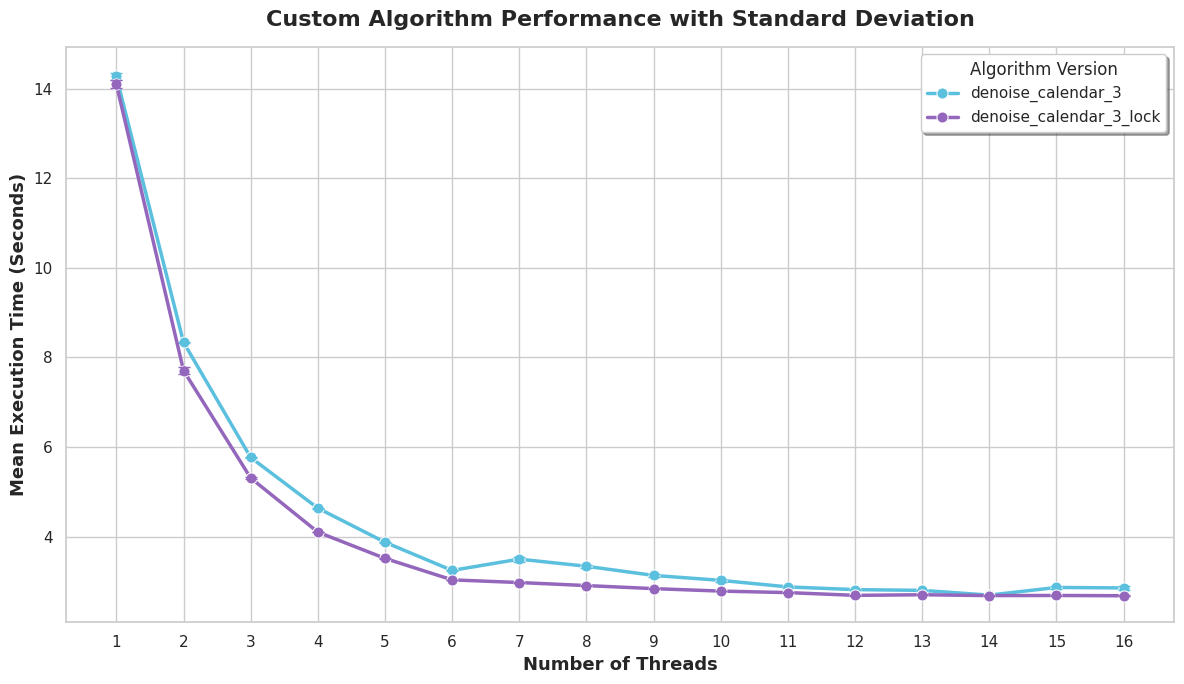

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
CSV_FILENAME = 'benchmark_results_detailed.csv'
OUTPUT_GRAPH = 'benchmark_custom_only_sd.png'

print(f"Loading data from {CSV_FILENAME}...")

try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'.")
    exit(1)

# --- FILTER OUT THE ORIGINAL BASELINE ---
# This line keeps only the rows where the Program Name is NOT 'denoise'
df = df[df['Program Name'] != 'denoise']

# Set up the plot style for a clean, academic look
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Define a custom color palette (excluding denoise)
custom_palette = {
    'denoise_calendar_1': '#8c564b',        # Brown (Naive)
    'denoise_calendar_dynamic_naive': '#f0ad4e', # Orange
    'denoise_calendar_3': '#5bc0de',        # Light Blue
    'denoise_calendar_final': '#5cb85c',        # Green (Optimized)
    'denoise_calendar_3_lock': '#9467bd'    # Purple
}

# --- THE PLOT ---
ax = sns.lineplot(
    data=df,
    x='Thread Count',
    y='Time (Seconds)',
    hue='Program Name',
    marker='o',
    markersize=8,
    linewidth=2.5,
    err_style="bars",      # Classic vertical error bars
    err_kws={'capsize': 4, 'elinewidth': 2}, # Adds caps to the bars
    errorbar=('ci', 99),         # Shows +/- 1 Standard Deviation
    palette=custom_palette
)

# Formatting
plt.title('Custom Algorithm Performance with Standard Deviation', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Threads', fontsize=13, fontweight='bold')
plt.ylabel('Mean Execution Time (Seconds)', fontsize=13, fontweight='bold')

# Ensure all thread counts are visible on the X-axis
thread_counts = sorted(df['Thread Count'].unique())
plt.xticks(thread_counts)

# Customize the legend
plt.legend(title='Algorithm Version', title_fontsize='12', fontsize='11', shadow=True)

# Save the graph
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")

# Display it on screen
plt.show()

Loading data from benchmark_results_detailed.csv...
✅ Graph successfully generated and saved as 'speedup_comparison_v3_vs_v3lock.png'!


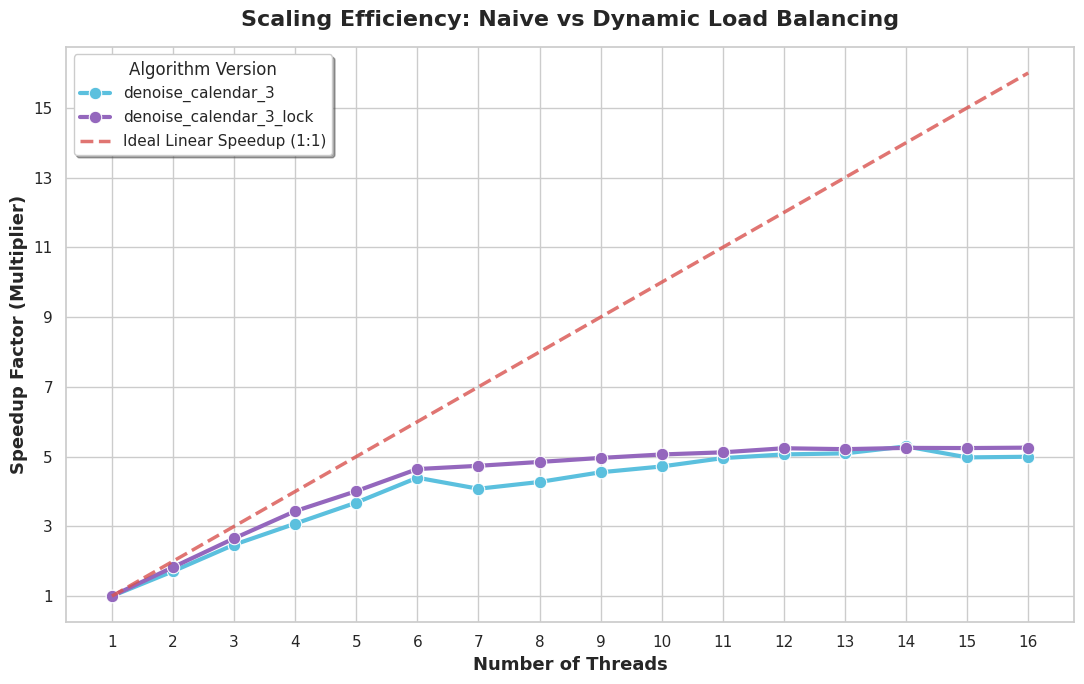

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
CSV_FILENAME = 'benchmark_results_detailed.csv'
OUTPUT_GRAPH = 'speedup_comparison_v3_vs_v3lock.png'
TARGET_PROGRAMS = ['denoise_calendar_3', 'denoise_calendar_3_lock']

print(f"Loading data from {CSV_FILENAME}...")

try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"Error: Could not find '{CSV_FILENAME}'.")
    exit(1)

# --- 1. FILTER AND AGGREGATE DATA ---
# Keep only the target programs
df_filtered = df[df['Program Name'].isin(TARGET_PROGRAMS)]

if df_filtered.empty:
    print(f"Error: No data found for the specified programs. Check your CSV.")
    exit(1)

# Calculate the MEAN time for each program and thread count combination
df_mean = df_filtered.groupby(['Program Name', 'Thread Count'])['Time (Seconds)'].mean().reset_index()

# --- 2. CALCULATE SPEEDUP FOR EACH PROGRAM ---
# Speedup = Time(1 thread) / Time(N threads)
# We calculate this relative to EACH program's own 1-thread baseline to show their scaling efficiency
df_mean['Actual Speedup'] = 0.0

for prog in TARGET_PROGRAMS:
    try:
        # Get the 1-thread time for this specific program
        t1_baseline = df_mean[(df_mean['Program Name'] == prog) & (df_mean['Thread Count'] == 1)]['Time (Seconds)'].values[0]
        
        # Calculate and assign the speedup
        mask = df_mean['Program Name'] == prog
        df_mean.loc[mask, 'Actual Speedup'] = t1_baseline / df_mean.loc[mask, 'Time (Seconds)']
    except IndexError:
        print(f"Warning: No 1-thread baseline data found for {prog}. Skipping speedup calculation.")

# --- 3. PLOT THE GRAPH ---
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

custom_palette = {
    'denoise_calendar_3': '#5bc0de',        # Light Blue
    'denoise_calendar_3_lock': '#9467bd'    # Purple
}

# Plot Actual Speedups
sns.lineplot(
    data=df_mean,
    x='Thread Count',
    y='Actual Speedup',
    hue='Program Name',
    marker='o',
    markersize=9,
    linewidth=3,
    palette=custom_palette
)

# Plot Ideal Linear Speedup (x = thread counts, y = thread counts)
thread_counts = sorted(df_mean['Thread Count'].unique())
plt.plot(
    thread_counts, 
    thread_counts, 
    linestyle='--', 
    color='#d9534f', 
    linewidth=2.5, 
    alpha=0.8,
    label='Ideal Linear Speedup (1:1)'
)

# Formatting
plt.title('Scaling Efficiency: Naive vs Dynamic Load Balancing', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Threads', fontsize=13, fontweight='bold')
plt.ylabel('Speedup Factor (Multiplier)', fontsize=13, fontweight='bold')

# Ensure X and Y axes have clean integer ticks
plt.xticks(thread_counts)
max_threads = max(thread_counts)
plt.yticks(range(1, max_threads + 1, 2))

# Customize the legend
plt.legend(title='Algorithm Version', title_fontsize='12', fontsize='11', shadow=True, loc='upper left')

# Save and show
plt.tight_layout()
plt.savefig(OUTPUT_GRAPH, dpi=300)
print(f"✅ Graph successfully generated and saved as '{OUTPUT_GRAPH}'!")
plt.show()